In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from datetime import datetime

# --- DISPLAY SETTINGS ---
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# --- PROJECT DIRECTORY ---
project_dir = "C:\\Users\\WORK-PC\\Downloads\\New folder\\"

# --- DATA LOADING ---
print("--- Loading Emade Datasets ---")
try:
    orders = pd.read_csv(os.path.join(project_dir, 'EmadeOrders.csv'), encoding='latin1')
    order_items = pd.read_csv(os.path.join(project_dir, 'EmadeOrderItems.csv'), encoding='latin1')
    products = pd.read_csv(os.path.join(project_dir, 'EmadeProducts.csv'), encoding='latin1')
    customers = pd.read_csv(os.path.join(project_dir, 'EmadeCustomers.csv'), encoding='latin1')
    categories = pd.read_csv(os.path.join(project_dir, 'EmadeCategories.csv'), encoding='latin1')
    brands = pd.read_csv(os.path.join(project_dir, 'EmadeBrands.csv'), encoding='latin1')
    stores = pd.read_csv(os.path.join(project_dir, 'EmadeStores.csv'), encoding='latin1')
    staffs = pd.read_csv(os.path.join(project_dir, 'EmadeStaffs.csv'), encoding='latin1')
    stocks = pd.read_csv(os.path.join(project_dir, 'EmadeStocks.csv'), encoding='latin1')
    print("All 9 datasets loaded successfully.")
except Exception as e:
    print(f"Error loading datasets: {e}")

# --- DATA INTEGRATION (Master DataFrame) ---
# Merging datasets to create a comprehensive view for analysis
df = order_items.merge(orders, on='order_id', how='left')
df = df.merge(products, on='product_id', how='left')
df = df.merge(customers, on='customer_id', how='left')
df = df.merge(categories, on='category_id', how='left')
df = df.merge(brands, on='brand_id', how='left')
df = df.merge(stores, on='store_id', how='left')

--- Loading Emade Datasets ---
All 9 datasets loaded successfully.


In [6]:
# Feature Engineering
df['revenue'] = df['quantity'] * df['list_price_x'] * (1 - df['discount'])
df['order_date'] = pd.to_datetime(df['order_date'])
df['month_year'] = df['order_date'].dt.to_period('M')
df['plan_id'] = df['category_id'] # Mapping category_id to plan_id as per user's request structure

In [5]:
# --- DATA CLEANING ---
print("\n--- Data Cleaning ---")
print("Missing values per column:\n", df.isnull().sum())
df.drop_duplicates(inplace=True)
print(f"Data types:\n{df.dtypes}")


--- Data Cleaning ---
Missing values per column:
 order_id            0
item_id             0
product_id          0
quantity            0
list_price_x        0
discount            0
customer_id         0
order_status        0
order_date          0
required_date       0
shipped_date      508
store_id            0
staff_id            0
product_name        0
brand_id            0
category_id         0
model_year          0
list_price_y        0
first_name          0
last_name           0
phone_x          4114
email_x             0
street_x            0
city_x              0
state_x             0
zip_code_x          0
category_name       0
brand_name          0
store_name          0
phone_y             0
email_y             0
street_y            0
city_y              0
state_y             0
zip_code_y          0
revenue             0
month_year          0
plan_id             0
dtype: int64
Data types:
order_id                  int64
item_id                   int64
product_id              

In [6]:
# --- DESCRIPTIVE STATISTICS ---
print("\n--- Descriptive Statistics ---")
print(df.describe(include='all'))


--- Descriptive Statistics ---
           order_id      item_id   product_id     quantity  list_price_x  \
count   4722.000000  4722.000000  4722.000000  4722.000000   4722.000000   
unique          NaN          NaN          NaN          NaN           NaN   
top             NaN          NaN          NaN          NaN           NaN   
freq            NaN          NaN          NaN          NaN           NaN   
mean     821.265354     2.262601    59.366158     1.498941   1212.707872   
min        1.000000     1.000000     2.000000     1.000000     89.990000   
25%      423.250000     1.000000    14.000000     1.000000    429.000000   
50%      828.500000     2.000000    28.000000     1.000000    599.990000   
75%     1226.000000     3.000000    84.000000     2.000000   1549.000000   
max     1615.000000     5.000000   315.000000     2.000000  11999.990000   
std      465.152168     1.199129    67.312708     0.500052   1352.798257   

           discount  customer_id  order_status         

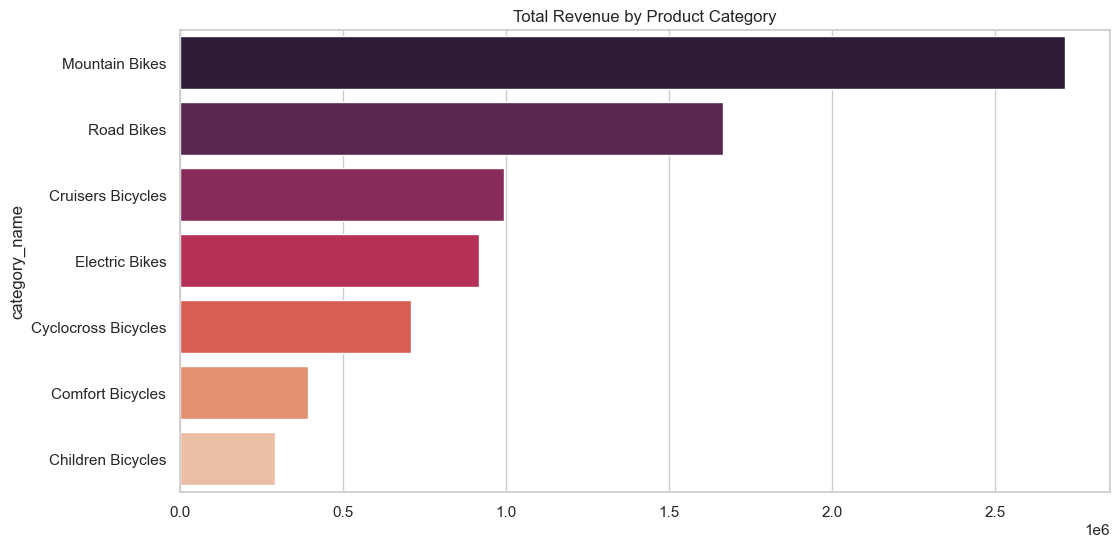

In [11]:
# --- 12 APPLICABLE VISUALIZATIONS ---
os.makedirs("emade_plots", exist_ok=True)

# 3. Total Revenue by Product Category (Bar Plot)
plt.figure(figsize=(12, 6))
cat_rev = df.groupby('category_name')['revenue'].sum().sort_values(ascending=False)
sns.barplot(x=cat_rev.values, y=cat_rev.index, palette='rocket', hue=cat_rev.index, legend=False)
plt.title("Total Revenue by Product Category")
plt.savefig("emade_plots/3_revenue_by_category.png")
plt.show()


In [24]:
def plot_membership_distribution(data: pd.DataFrame, 
                                figsize: tuple = (10, 6),
                                save_path: str = "emade_plots/1_membership_distribution.png") -> None:
    """
    Creates and saves a count plot showing the distribution of membership plans
    with count values displayed on top of each bar.
    
    Args:
        data (pd.DataFrame): DataFrame containing membership data with 'plan_id' column
        figsize (tuple, optional): Figure size as (width, height). Defaults to (10, 6).
        save_path (str, optional): Path to save the generated plot. 
                                  Defaults to "emade_plots/1_membership_distribution.png".
    
    Returns:
        None: The function saves the plot to the specified path and displays it.
    """
    plt.figure(figsize=figsize)
    
    # Create the count plot
    ax = sns.countplot(x='plan_id', 
                      data=data, 
                      palette='viridis', 
                      hue='plan_id', 
                      legend=True)
    
    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,  # x position: center of the bar
            height + 0.1,                     # y position: slightly above the bar
            f'{int(height)}',                 # text: count value as integer
            ha="center",                      # horizontal alignment
            fontsize=10                       # font size
        )
    
    plt.title("Distribution of Membership with Plans (Category ID)")
    plt.savefig(save_path)
    plt.show()

# Usage example:
# plot_membership_distribution(df)

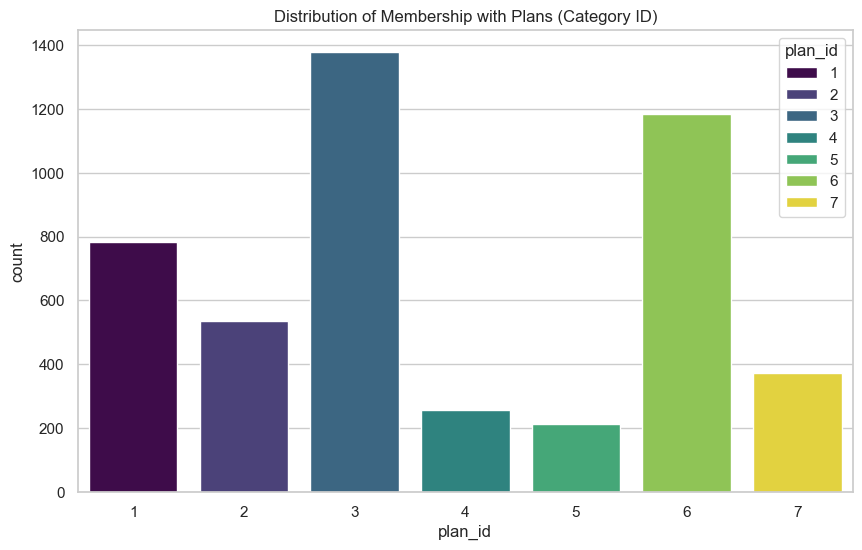

In [22]:
# 1. Distribution of Membership with Plans (Count Plot)
plt.figure(figsize=(10, 6))
sns.countplot(x='plan_id', data=df, palette='viridis', hue='plan_id', legend=True)
plt.title("Distribution of Membership with Plans (Category ID)")
plt.savefig("emade_plots/1_membership_distribution.png")
plt.show()

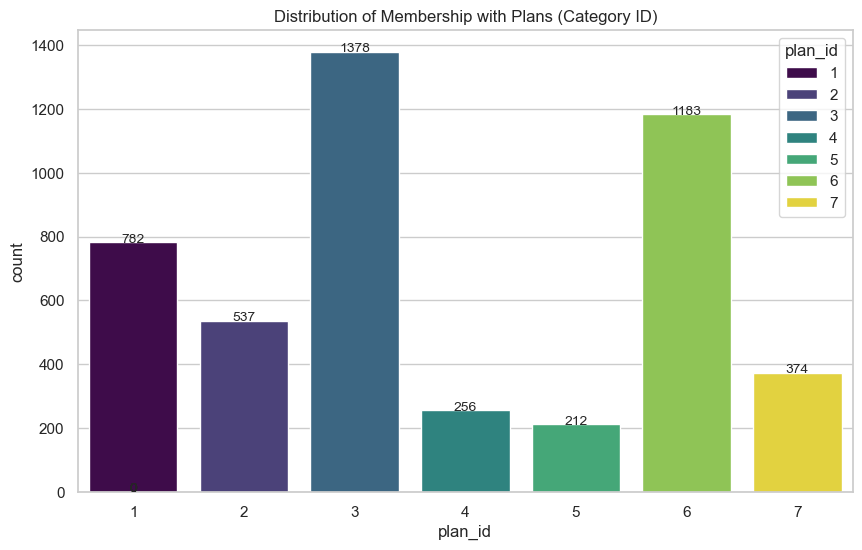

In [27]:
def plot_membership_distribution(data: pd.DataFrame, 
                                figsize: tuple = (10, 6),
                                save_path: str = "emade_plots/1_membership_distribution.png") -> None:
    """
    Creates and saves a count plot showing the distribution of membership plans
    with count values displayed on top of each bar.
    
    Args:
        data (pd.DataFrame): DataFrame containing membership data with 'plan_id' column
        figsize (tuple, optional): Figure size as (width, height). Defaults to (10, 6).
        save_path (str, optional): Path to save the generated plot. 
                                  Defaults to "emade_plots/1_membership_distribution.png".
    
    Returns:
        None: The function saves the plot to the specified path and displays it.
    """
    plt.figure(figsize=figsize)
    
    # Create the count plot
    ax = sns.countplot(x='plan_id', 
                      data=data, 
                      palette='viridis', 
                      hue='plan_id', 
                      legend=True)
    
    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,  # x position: center of the bar
            height + 0.1,                     # y position: slightly above the bar
            f'{int(height)}',                 # text: count value as integer
            ha="center",                      # horizontal alignment
            fontsize=10                       # font size
        )
    
    plt.title("Distribution of Membership with Plans (Category ID)")
    plt.savefig(save_path)
    plt.show()

# Usage example:
plot_membership_distribution(df)

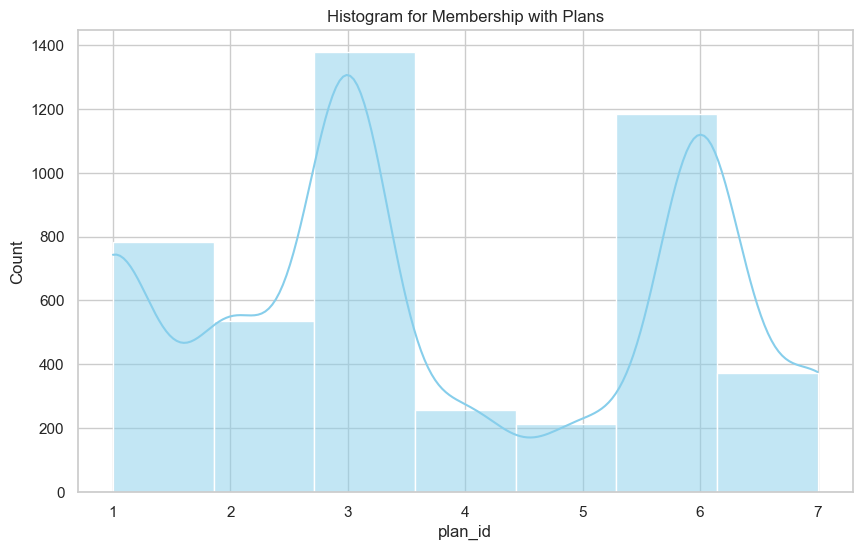

In [13]:
# 2. Histogram for Membership with Plans
plt.figure(figsize=(10, 6))
sns.histplot(df['plan_id'], kde=True, bins=7, color='skyblue')
plt.title("Histogram for Membership with Plans")
plt.savefig("emade_plots/2_membership_histogram.png")
plt.show()

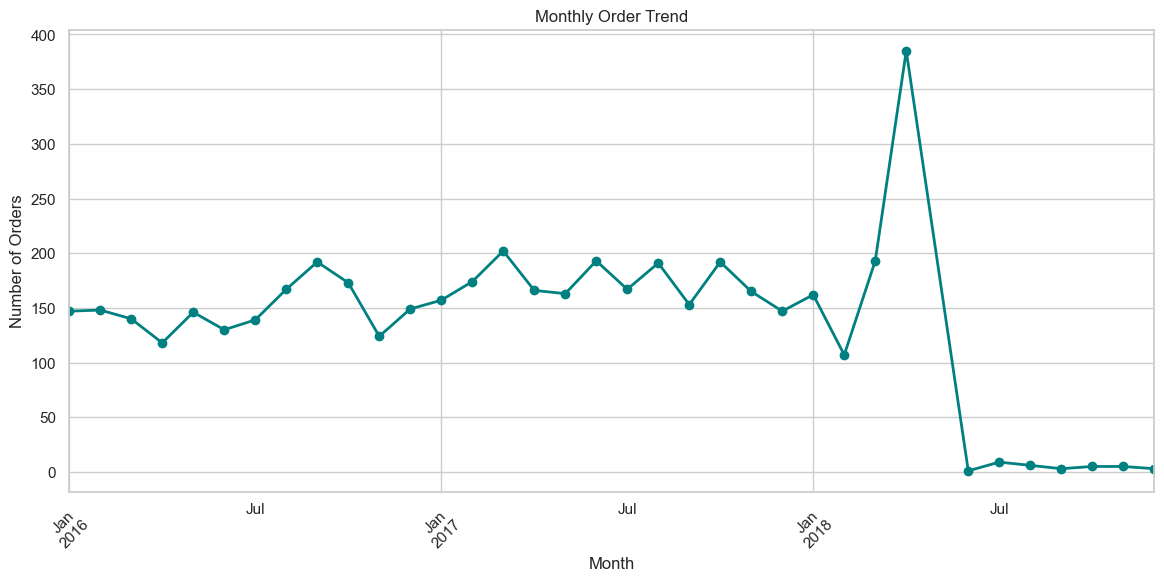

In [14]:
# 4. Monthly Order Trend (Line Plot)
plt.figure(figsize=(14, 6))
monthly_orders = df.groupby('month_year').size()
monthly_orders.plot(kind='line', marker='o', color='teal', linewidth=2)
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.savefig("emade_plots/4_monthly_trend.png")
plt.show()

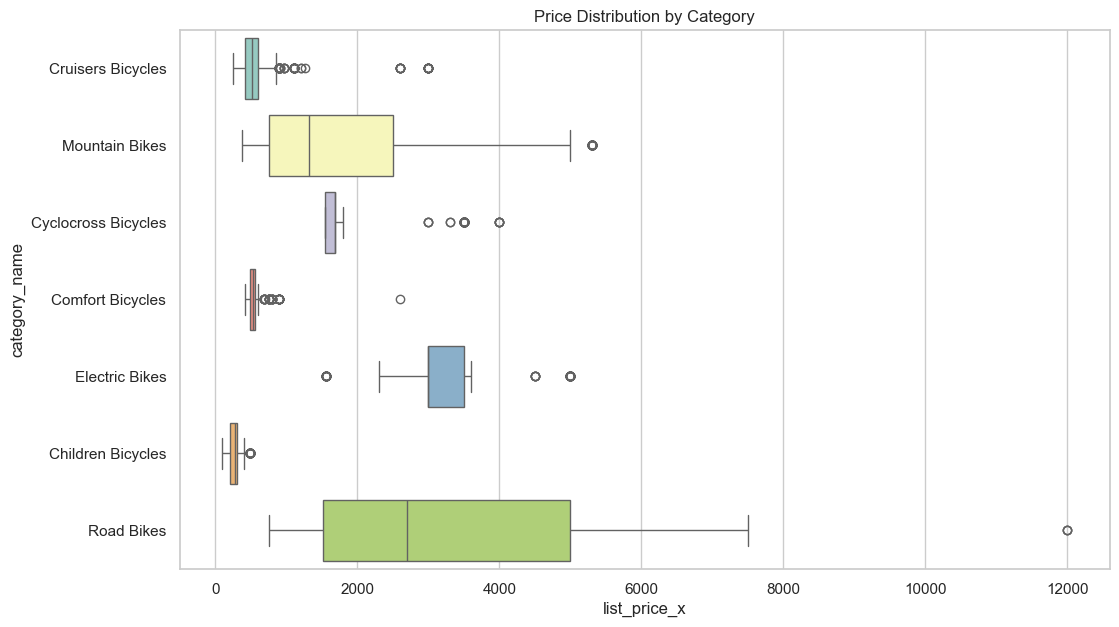

In [15]:
# 5. Price Distribution by Category (Box Plot)
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='list_price_x', y='category_name', palette='Set3', hue='category_name', legend=False)
plt.title("Price Distribution by Category")
plt.savefig("emade_plots/5_price_distribution.png")
plt.show()

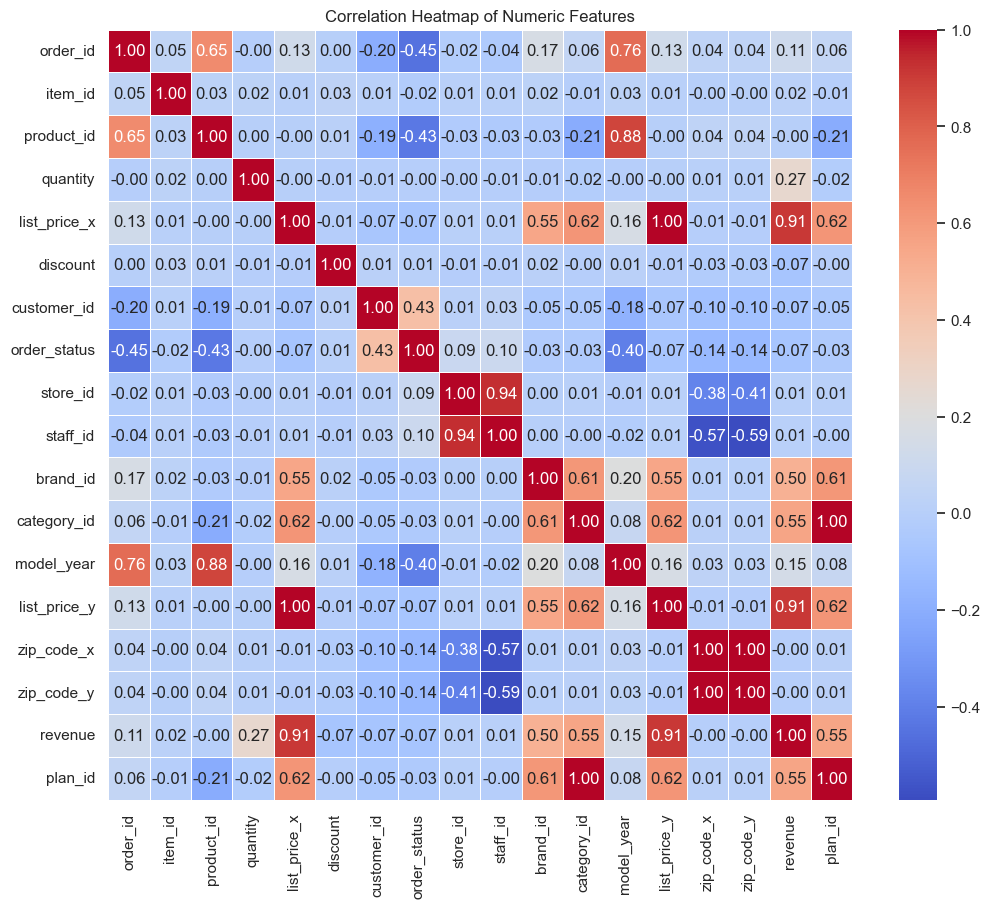

In [16]:
# 6. Correlation Heatmap (Numeric Variables)
plt.figure(figsize=(12, 10))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig("emade_plots/6_correlation_heatmap.png")
plt.show()

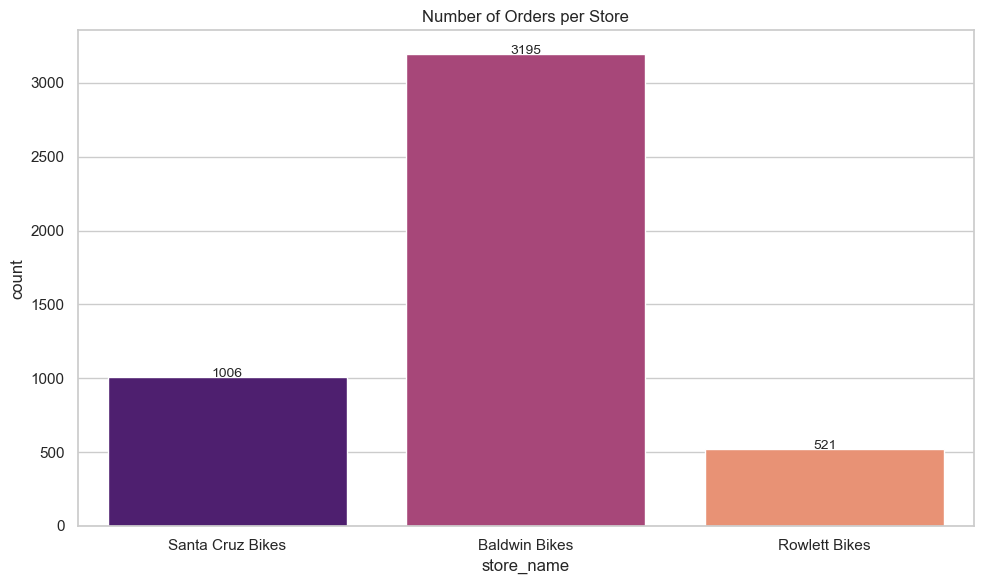

In [28]:
def plot_orders_per_store(data: pd.DataFrame, figsize: tuple = (10, 6), 
                         palette: str = 'magma', output_path: str = "emade_plots/7_orders_per_store.png") -> None:
    """
    Creates and saves a count plot showing the number of orders per store with count labels.
    
    Args:
        data (pd.DataFrame): DataFrame containing store_name column
        figsize (tuple, optional): Figure size as (width, height). Defaults to (10, 6).
        palette (str, optional): Color palette for the plot. Defaults to 'magma'.
        output_path (str, optional): Path to save the output figure. Defaults to "emade_plots/7_orders_per_store.png".
    
    Returns:
        None: The function saves the plot to a file and displays it.
    """
    plt.figure(figsize=figsize)
    
    # Create the count plot
    ax = sns.countplot(data=data, x='store_name', palette=palette, hue='store_name', legend=False)
    
    # Add count labels on top of each bar
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2.,  # x position: center of the bar
            height + 0.1,                     # y position: slightly above the bar
            f'{int(height)}',                 # text: count value as integer
            ha="center",                      # horizontal alignment: centered
            fontsize=10                       # font size
        )
    
    plt.title("Number of Orders per Store")
    plt.tight_layout()  # Adjust layout to make room for labels
    plt.savefig(output_path)
    plt.show()

# Usage example:
plot_orders_per_store(df)

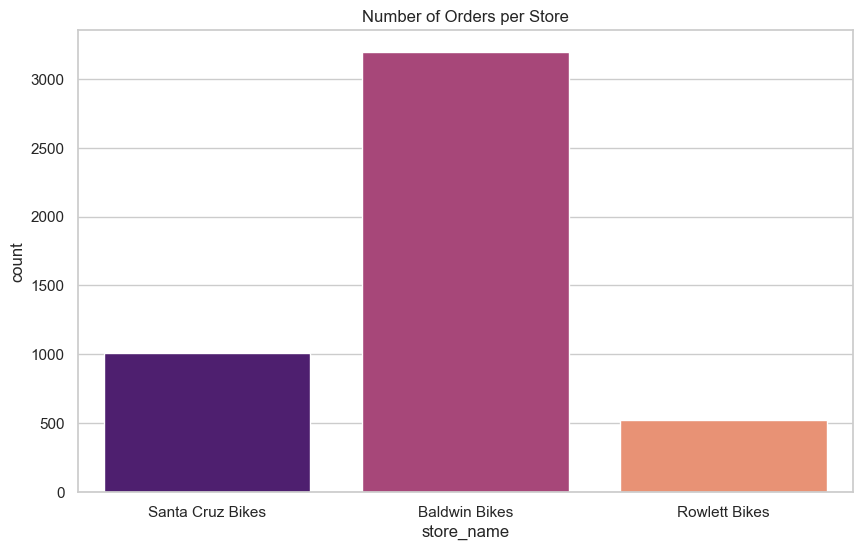

In [17]:
# 7. Orders per Store (Count Plot)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='store_name', palette='magma', hue='store_name', legend=False)
plt.title("Number of Orders per Store")
plt.savefig("emade_plots/7_orders_per_store.png")
plt.show()

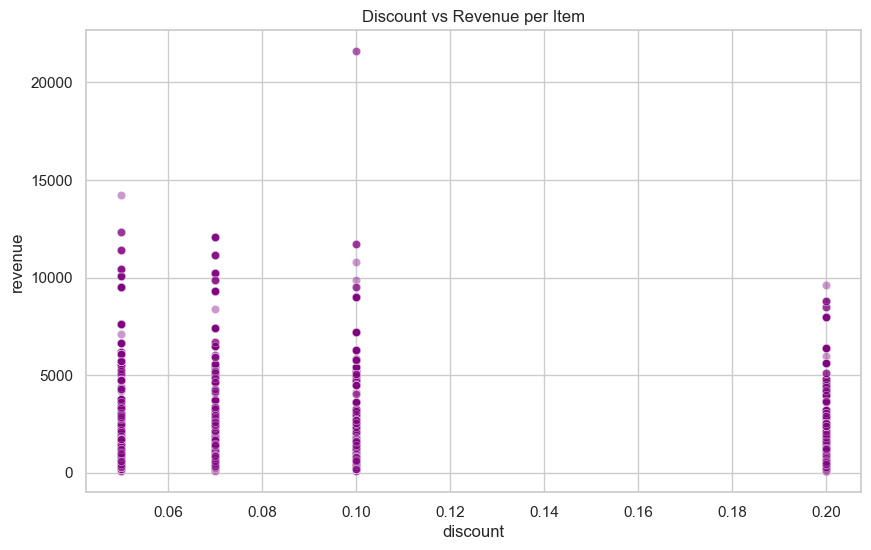

In [18]:
# 8. Discount vs Revenue (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='discount', y='revenue', alpha=0.4, color='purple')
plt.title("Discount vs Revenue per Item")
plt.savefig("emade_plots/8_discount_vs_revenue.png")
plt.show()

C:\Users\WORK-PC\AppData\Local\Temp\ipykernel_23652\3686542634.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=brand_rev.values, y=brand_rev.index, palette=colors)


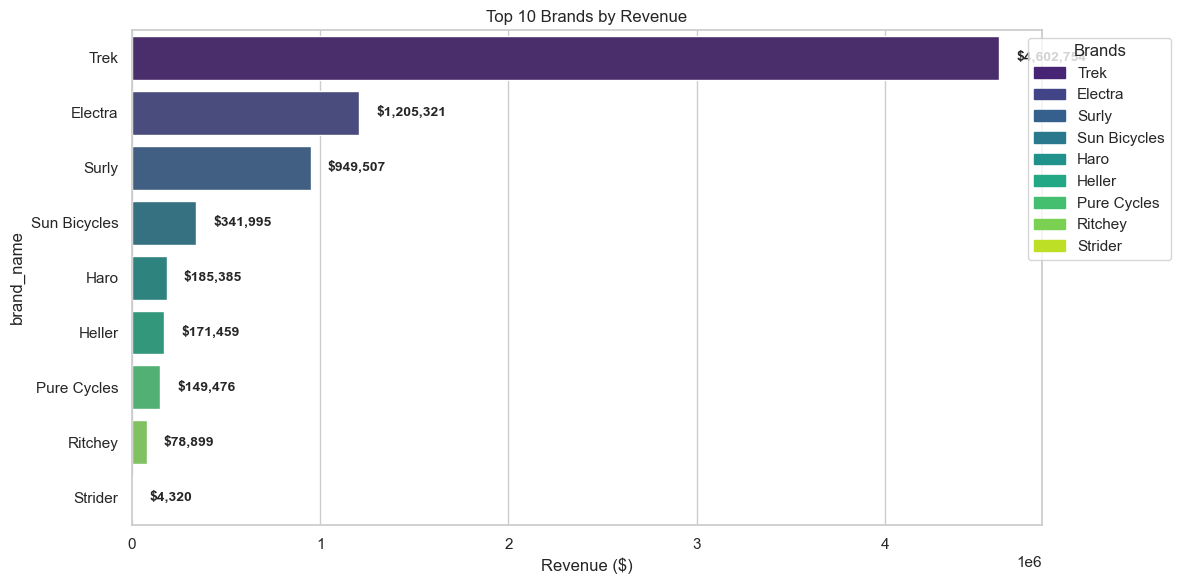

In [30]:
def plot_top_brands_by_revenue(df: pd.DataFrame, n_brands: int = 10, 
                              figsize: tuple = (12, 6), color_palette: str = 'viridis',
                              output_path: str = "emade_plots/9_top_brands.png") -> None:
    """
    Creates and saves a bar plot showing the top N brands by revenue with revenue values labeled
    and each brand having a distinct color.
    
    Args:
        df (pd.DataFrame): DataFrame containing brand_name and revenue columns
        n_brands (int, optional): Number of top brands to display. Defaults to 10.
        figsize (tuple, optional): Figure size as (width, height). Defaults to (12, 6).
        color_palette (str, optional): Color palette for the plot. Defaults to 'viridis'.
        output_path (str, optional): Path to save the output figure. Defaults to "emade_plots/9_top_brands.png".
    
    Returns:
        None: The function saves the plot to a file and displays it.
    """
    plt.figure(figsize=figsize)
    
    # Calculate top brands by revenue
    brand_rev = df.groupby('brand_name')['revenue'].sum().nlargest(n_brands)
    
    # Generate a color palette with distinct colors for each brand
    colors = sns.color_palette(color_palette, n_colors=len(brand_rev))
    
    # Create the bar plot with individual colors
    ax = sns.barplot(x=brand_rev.values, y=brand_rev.index, palette=colors)
    
    # Add revenue labels to each bar
    for i, revenue in enumerate(brand_rev.values):
        # Format revenue value for display (e.g., add commas for thousands)
        formatted_revenue = f"${revenue:,.0f}"
        
        ax.text(
            revenue + (brand_rev.max() * 0.02),  # x position: slightly right of the bar end
            i,                                   # y position: bar index
            formatted_revenue,                   # text: formatted revenue value
            va='center',                         # vertical alignment: centered with the bar
            fontweight='bold',                   # make text bold
            fontsize=10                          # font size
        )
    
    plt.title("Top 10 Brands by Revenue")
    plt.xlabel("Revenue ($)")
    
    # Add a color legend
    handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(brand_rev))]
    plt.legend(handles, brand_rev.index, title="Brands", loc='upper right', 
               bbox_to_anchor=(1.15, 1), frameon=True)
    
    plt.tight_layout()  # Adjust layout to make room for labels and legend
    plt.savefig(output_path)
    plt.show()

# Usage example:
plot_top_brands_by_revenue(df)

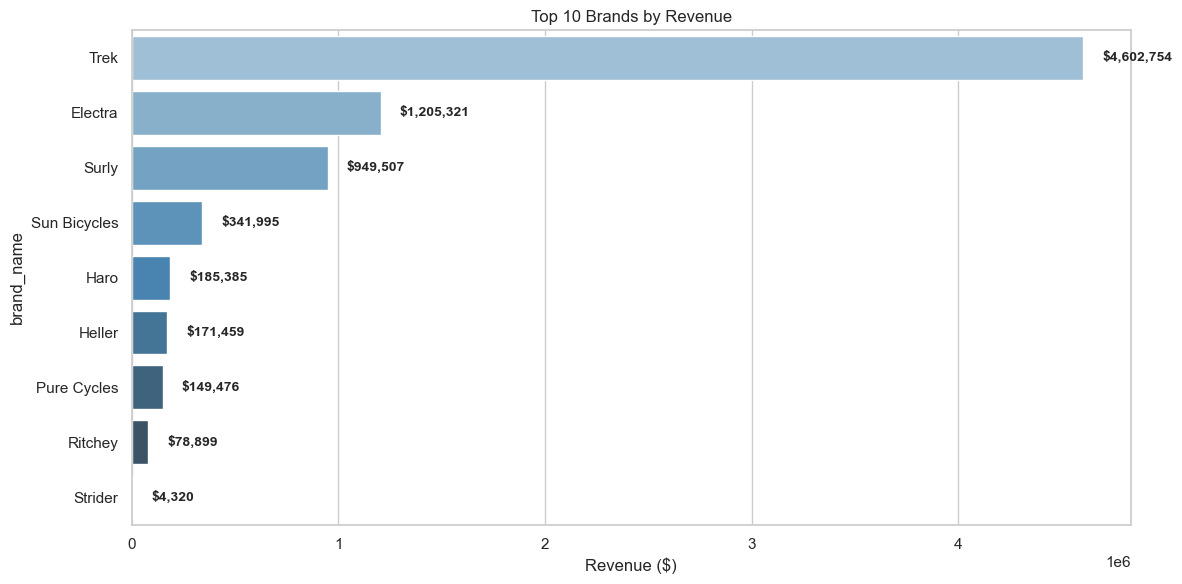

In [29]:
def plot_top_brands_by_revenue(df: pd.DataFrame, n_brands: int = 10, 
                              figsize: tuple = (12, 6), palette: str = 'Blues_d',
                              output_path: str = "emade_plots/9_top_brands.png") -> None:
    """
    Creates and saves a bar plot showing the top N brands by revenue with revenue values labeled.
    
    Args:
        df (pd.DataFrame): DataFrame containing brand_name and revenue columns
        n_brands (int, optional): Number of top brands to display. Defaults to 10.
        figsize (tuple, optional): Figure size as (width, height). Defaults to (12, 6).
        palette (str, optional): Color palette for the plot. Defaults to 'Blues_d'.
        output_path (str, optional): Path to save the output figure. Defaults to "emade_plots/9_top_brands.png".
    
    Returns:
        None: The function saves the plot to a file and displays it.
    """
    plt.figure(figsize=figsize)
    
    # Calculate top brands by revenue
    brand_rev = df.groupby('brand_name')['revenue'].sum().nlargest(n_brands)
    
    # Create the bar plot
    ax = sns.barplot(x=brand_rev.values, y=brand_rev.index, palette=palette, 
                    hue=brand_rev.index, legend=False)
    
    # Add revenue labels to each bar
    for i, revenue in enumerate(brand_rev.values):
        # Format revenue value for display (e.g., add commas for thousands)
        formatted_revenue = f"${revenue:,.0f}"
        
        ax.text(
            revenue + (brand_rev.max() * 0.02),  # x position: slightly right of the bar end
            i,                                   # y position: bar index
            formatted_revenue,                   # text: formatted revenue value
            va='center',                         # vertical alignment: centered with the bar
            fontweight='bold',                   # make text bold
            fontsize=10                          # font size
        )
    
    plt.title("Top 10 Brands by Revenue")
    plt.xlabel("Revenue ($)")
    plt.tight_layout()  # Adjust layout to make room for labels
    plt.savefig(output_path)
    plt.show()

# Usage example:
plot_top_brands_by_revenue(df)

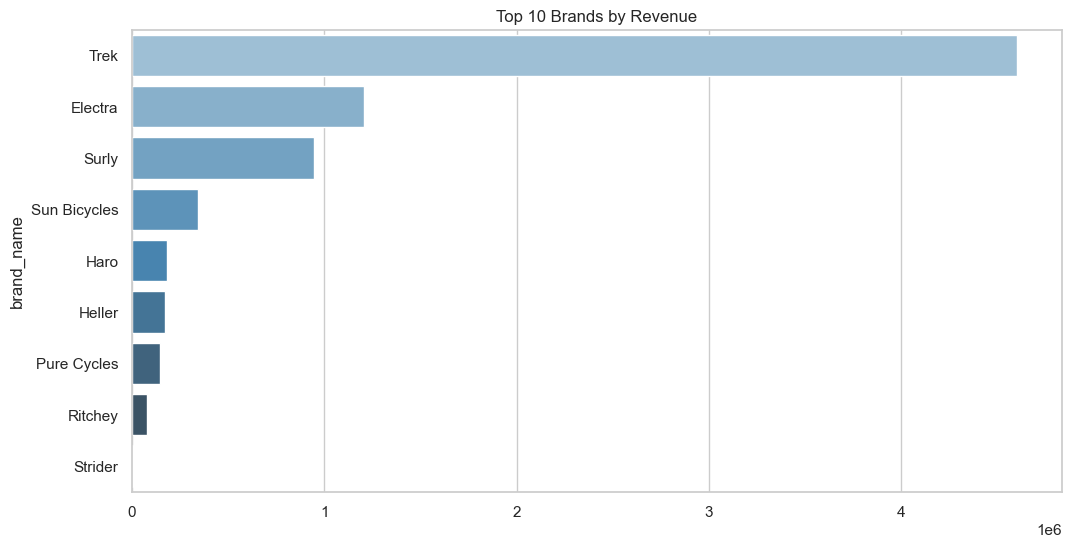

In [19]:
# 9. Top 10 Brands by Revenue (Bar Plot)
plt.figure(figsize=(12, 6))
brand_rev = df.groupby('brand_name')['revenue'].sum().nlargest(10)
sns.barplot(x=brand_rev.values, y=brand_rev.index, palette='Blues_d', hue=brand_rev.index, legend=False)
plt.title("Top 10 Brands by Revenue")
plt.savefig("emade_plots/9_top_brands.png")
plt.show()

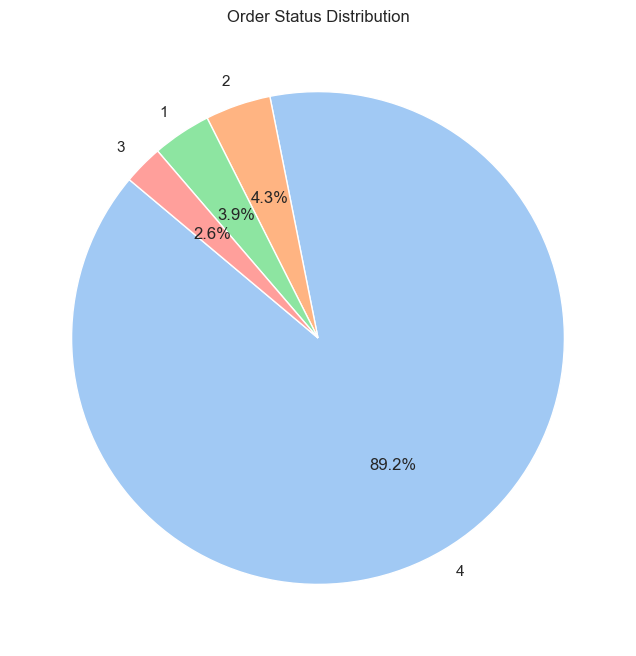

In [20]:
# 10. Order Status Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
status_counts = df['order_status'].value_counts()
plt.pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Order Status Distribution")
plt.savefig("emade_plots/10_order_status_pie.png")
plt.show()

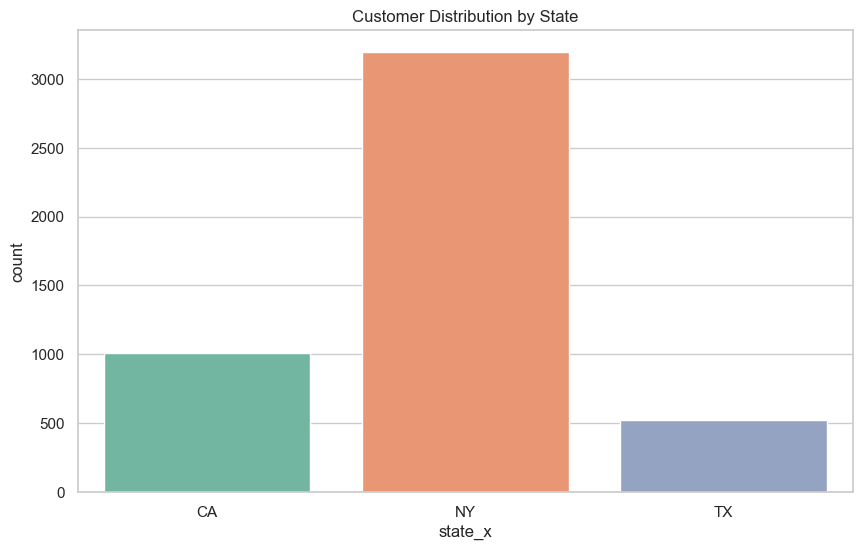

In [21]:
# 11. Customer Geographic Distribution (State-wise)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='state_x', palette='Set2', hue='state_x', legend=False)
plt.title("Customer Distribution by State")
plt.savefig("emade_plots/11_state_distribution.png")
plt.show()

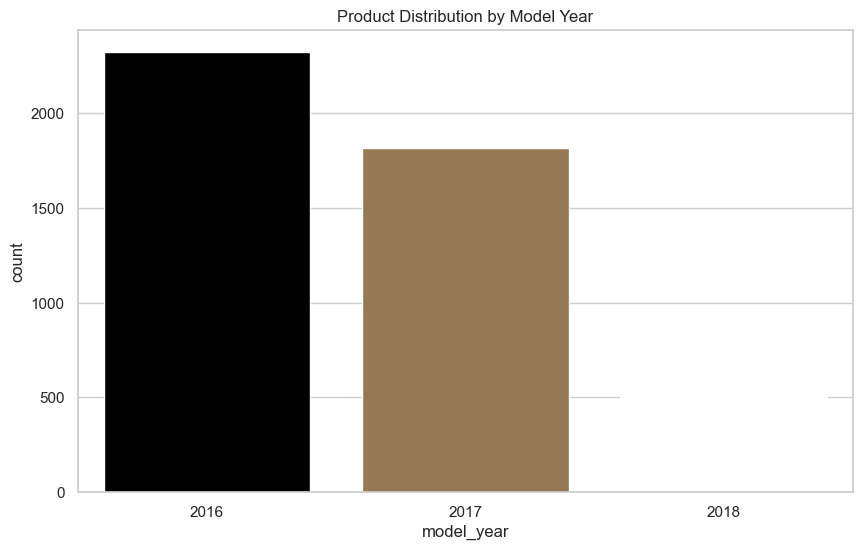

In [7]:
# 12. Model Year Distribution (Count Plot)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from datetime import datetime

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='model_year', palette='cubehelix', hue='model_year', legend=False)
plt.title("Product Distribution by Model Year")
plt.savefig("emade_plots/12_model_year_dist.png")
plt.show()

In [1]:
import pandas as pd
import os
from sqlalchemy import create_engine
import urllib

# --- CONFIGURATION ---
project_dir = "C:\\Users\\WORK-PC\\Downloads\\New folder\\"

# Connection string from the C# snippet adapted for Python (SQLAlchemy)
server = 'DESKTOP-GO1QVHO'
database = 'EmadeDev'
connection_string = f"DRIVER={{ODBC Driver 17 for SQL Server}};SERVER={server};DATABASE={database};Trusted_Connection=yes"

# Create SQLAlchemy engine
params = urllib.parse.quote_plus(connection_string)
engine = create_engine(f"mssql+pyodbc:///?odbc_connect={params}")

def migrate_csvs():
    # Iterate through files in the specified project directory
    if not os.path.exists(project_dir):
        print(f"Error: Project directory not found at {project_dir}")
        return

    files = [f for f in os.listdir(project_dir) if f.endswith('.csv')]
    
    print(f"Found {len(files)} CSV files in {project_dir} for migration.")
    
    for file in files:
        # 1. Define table name: Remove .csv and append PH
        table_name = os.path.splitext(file)[0] + "PH"
        
        print(f"--- Migrating {file} to table {table_name} ---")
        
        try:
            # 2. Read CSV into DataFrame from the project_dir
            file_path = os.path.join(project_dir, file)
            df = pd.read_csv(file_path, encoding='latin1')
            
            # 3. Write to SQL Server
            # if_exists='replace' will drop the table if it exists and recreate it
            df.to_sql(table_name, con=engine, if_exists='replace', index=False)
            
            print(f"Successfully migrated {len(df)} rows to {table_name}.")
            
        except Exception as e:
            print(f"Error migrating {file}: {e}")

if __name__ == "__main__":
    migrate_csvs()


Found 9 CSV files in C:\Users\WORK-PC\Downloads\New folder\ for migration.
--- Migrating EmadeBrands.csv to table EmadeBrandsPH ---
Successfully migrated 9 rows to EmadeBrandsPH.
--- Migrating EmadeCategories.csv to table EmadeCategoriesPH ---
Successfully migrated 7 rows to EmadeCategoriesPH.
--- Migrating EmadeCustomers.csv to table EmadeCustomersPH ---
Successfully migrated 1445 rows to EmadeCustomersPH.
--- Migrating EmadeOrderItems.csv to table EmadeOrderItemsPH ---
Successfully migrated 4722 rows to EmadeOrderItemsPH.
--- Migrating EmadeOrders.csv to table EmadeOrdersPH ---
Successfully migrated 1615 rows to EmadeOrdersPH.
--- Migrating EmadeProducts.csv to table EmadeProductsPH ---
Successfully migrated 321 rows to EmadeProductsPH.
--- Migrating EmadeStaffs.csv to table EmadeStaffsPH ---
Successfully migrated 10 rows to EmadeStaffsPH.
--- Migrating EmadeStocks.csv to table EmadeStocksPH ---
Successfully migrated 939 rows to EmadeStocksPH.
--- Migrating EmadeStores.csv to table E